# Notebook 02 - Precision Levels

This notebook makes four versions of the clean table, the original and three with less precision, and measures how much storage each one takes. All of them are Parquet with zstd, so the only thing that changes between them is the precision. It also adds the keys that notebooks 03 and 04 use, the trip id, the time split and the 20% sample.

**Input** `hdfs:///ca1/clean/yellow_2024q1`. **Output** `hdfs:///ca1/levels/storage`, `hdfs:///ca1/levels/train`, `results/02_levels.csv`, `figures/02_levels.png`.

### Step 1 - Import Libraries

In [1]:
# PySpark
import pyspark                                    # Python API for Spark
from pyspark.sql import SparkSession              # entry point to Spark SQL
from pyspark.sql import functions as F            # column functions for rounding, dates and counts
print("PySpark: %s" % pyspark.__version__)        # print version

# Data manipulation
import pandas as pd                               # tables for the results
print("pandas: %s" % pd.__version__)              # print version

# Visualization
import matplotlib.pyplot as plt                   # charts

# Other utilities
import os                                         # folders on the local disk

# Same chart and table settings in every notebook (as in CA02)
def jupyter_settings():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "savefig.bbox": "tight",
        "savefig.dpi": 120,
    })
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.float_format", "{:,.2f}".format)

jupyter_settings()

PySpark: 4.2.0


pandas: 2.3.3


### Step 2 - Spark Session and Paths

Same settings as notebook 01. `/tmp` in this VM lives in RAM, so Spark's scratch files go to `~/spark-tmp` on the disk.

In [2]:
spark = (SparkSession.builder
         .master("local[4]")
         .appName("ca1-02-precision-levels")
         .config("spark.driver.memory", "3g")
         .config("spark.sql.session.timeZone", "UTC")
         .config("spark.local.dir", os.path.expanduser("~/spark-tmp"))   # scratch files on the disk, not in RAM
         .config("spark.sql.shuffle.partitions", 8)
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

BASE = "hdfs://localhost:9000/ca1"
CLEAN = f"{BASE}/clean/yellow_2024q1"                      # clean base from notebook 00
KEYED = f"{BASE}/clean/yellow_2024q1_keyed"                # clean base with the keys, written once
LEVELS_OUT = f"{BASE}/levels"

RESULTS = os.path.expanduser("~/ca1/results")
FIGURES = os.path.expanduser("~/ca1/figures")
for folder in [RESULTS, FIGURES]:
    os.makedirs(folder, exist_ok=True)

# Size of a folder on HDFS in bytes, the same number as `hdfs dfs -du -s`
hadoop = spark._jvm.org.apache.hadoop
fs = hadoop.fs.FileSystem.get(spark._jvm.java.net.URI(BASE), spark._jsc.hadoopConfiguration())
def hdfs_size(path):
    return fs.getContentSummary(hadoop.fs.Path(path)).getLength()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/10/08 08:19:36 WARN Utils: Your hostname, BDSP, resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/10/08 08:19:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/08 08:19:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/10/08 08:19:37 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


### Step 3 - Keys

Three keys are added before any precision is removed.

- `trip_id` is a unique number for each trip.
- `split` puts January and February in training, 1 to 15 March in validation and 16 to 31 March in test. The split follows time, so the network is always scored on trips that happen after the ones it learned from (Kapoor and Narayanan, 2023).
- `in_sample` marks 20% of the trips. It comes from a hash of the trip id, so the same trips are picked at every level.

The table with the keys is written once and read back, so the ids can never change between levels.

In [3]:
PAYLOAD = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_distance", "PULocationID", "DOLocationID"]   # the columns that lose precision
base = spark.read.parquet(CLEAN).select(*PAYLOAD, "duration_s_true").orderBy("tpep_pickup_datetime")

start_val = F.lit("2024-03-01 00:00:00").cast("timestamp_ntz")
start_test = F.lit("2024-03-16 00:00:00").cast("timestamp_ntz")

keyed = (base
         .withColumn("trip_id", F.monotonically_increasing_id())                   # a unique number for each trip
         .withColumn("split", F.when(base["tpep_pickup_datetime"] < start_val, "train")
                               .when(base["tpep_pickup_datetime"] < start_test, "validation")
                               .otherwise("test"))                                  # split by time, never at random
         .withColumn("in_sample", F.pmod(F.xxhash64("trip_id"), F.lit(100)) < 20))  # True for 20% of the trips, always the same ones

# Written once and read back, so the ids can never change
keyed.write.mode("overwrite").option("compression", "zstd").parquet(KEYED)
keyed = spark.read.parquet(KEYED)
keyed.groupBy("split").count().orderBy("split").show()

+----------+-------+
|     split|  count|
+----------+-------+
|      test|1768529|
|     train|5764483|
|validation|1680517|
+----------+-------+



### Step 4 - The Four Levels

| Level | Change |
|---|---|
| L0 | original data |
| D1 | distance rounded to 1 decimal |
| D0 | distance rounded to whole miles |
| T15 | both timestamps cut to 15-minute blocks |

In [4]:
def floor_ts(col, seconds):
    # rounds a timestamp down to the start of its block (900 seconds = 15 minutes)
    return F.timestamp_seconds(F.floor(F.unix_timestamp(col) / seconds) * seconds).cast("timestamp_ntz")

LEVELS = {
    "L0":  keyed,                                                                   # original data
    "D1":  keyed.withColumn("trip_distance", F.round("trip_distance", 1)),          # distance with 1 decimal
    "D0":  keyed.withColumn("trip_distance", F.round("trip_distance", 0)),          # distance in whole miles
    "T15": keyed.withColumn("tpep_pickup_datetime", floor_ts("tpep_pickup_datetime", 900))
                .withColumn("tpep_dropoff_datetime", floor_ts("tpep_dropoff_datetime", 900)),   # both timestamps in 15-minute blocks
}

### Step 5 - Checking Five Trips

The same five trips at three levels, to check that only the intended column changed.

In [5]:
ids = [row["trip_id"] for row in keyed.limit(5).collect()]
for name in ["L0", "D0", "T15"]:
    print(name)
    LEVELS[name].filter(F.col("trip_id").isin(ids)).select("trip_id", "tpep_pickup_datetime", "trip_distance").show()

L0


+-------+--------------------+-------------+
|trip_id|tpep_pickup_datetime|trip_distance|
+-------+--------------------+-------------+
|      0| 2024-01-01 00:00:00|          0.3|
|      1| 2024-01-01 00:00:02|         1.57|
|      2| 2024-01-01 00:00:03|          0.5|
|      3| 2024-01-01 00:00:04|         7.37|
|      4| 2024-01-01 00:00:05|        18.85|
+-------+--------------------+-------------+

D0


+-------+--------------------+-------------+
|trip_id|tpep_pickup_datetime|trip_distance|
+-------+--------------------+-------------+
|      0| 2024-01-01 00:00:00|          0.0|
|      1| 2024-01-01 00:00:02|          2.0|
|      2| 2024-01-01 00:00:03|          1.0|
|      3| 2024-01-01 00:00:04|          7.0|
|      4| 2024-01-01 00:00:05|         19.0|
+-------+--------------------+-------------+

T15


+-------+--------------------+-------------+
|trip_id|tpep_pickup_datetime|trip_distance|
+-------+--------------------+-------------+
|      0| 2024-01-01 00:00:00|          0.3|
|      1| 2024-01-01 00:00:00|         1.57|
|      2| 2024-01-01 00:00:00|          0.5|
|      3| 2024-01-01 00:00:00|         7.37|
|      4| 2024-01-01 00:00:00|        18.85|
+-------+--------------------+-------------+



### Step 6 - Writing and Weighing Each Level

Each level is written twice.

- The first copy has only the five columns that lose precision and every trip. This is the copy that is weighed, so the size reflects the precision and nothing else.
- The second copy has every column but only the 20% sample. This is the copy the network reads in notebooks 03 and 04.

The cell also counts how many different distances and pickup times are left, because Parquet stores repeated values very cheaply, so fewer different values means a smaller file.

In [6]:
rows = []
for name, df in LEVELS.items():
    # Copy 1, only the five payload columns and every trip. This is the copy that is weighed.
    df.select(*PAYLOAD).write.mode("overwrite").option("compression", "zstd").parquet(f"{LEVELS_OUT}/storage/{name}")
    # Copy 2, the 20% sample with every column. This is the copy the network reads.
    df.filter(df["in_sample"]).write.mode("overwrite").option("compression", "zstd").parquet(f"{LEVELS_OUT}/train/{name}")

    stored = spark.read.parquet(f"{LEVELS_OUT}/storage/{name}")
    distinct = stored.agg(F.countDistinct("trip_distance").alias("distances"),
                          F.approx_count_distinct("tpep_pickup_datetime", 0.01).alias("pickups")).first()   # pickups are approximate, there are millions
    rows.append({"level": name, "payload_mb": hdfs_size(f"{LEVELS_OUT}/storage/{name}") / 1e6,
                 "distinct_distances": distinct["distances"], "distinct_pickups": distinct["pickups"]})
    print(name, "written")

summary = pd.DataFrame(rows).set_index("level")
summary["size_vs_L0_pct"] = summary["payload_mb"] / summary.loc["L0", "payload_mb"] * 100
summary

L0 written


D1 written


D0 written


T15 written


,payload_mb,distinct_distances,distinct_pickups,size_vs_L0_pct
level,,,,
L0,76.02,3857,4678340,100.00
D1,72.57,493,4678340,95.46
D0,67.79,67,4678340,89.17
T15,32.46,3857,8647,42.69


*Result - to be written after the run.*

### Step 7 - Chart

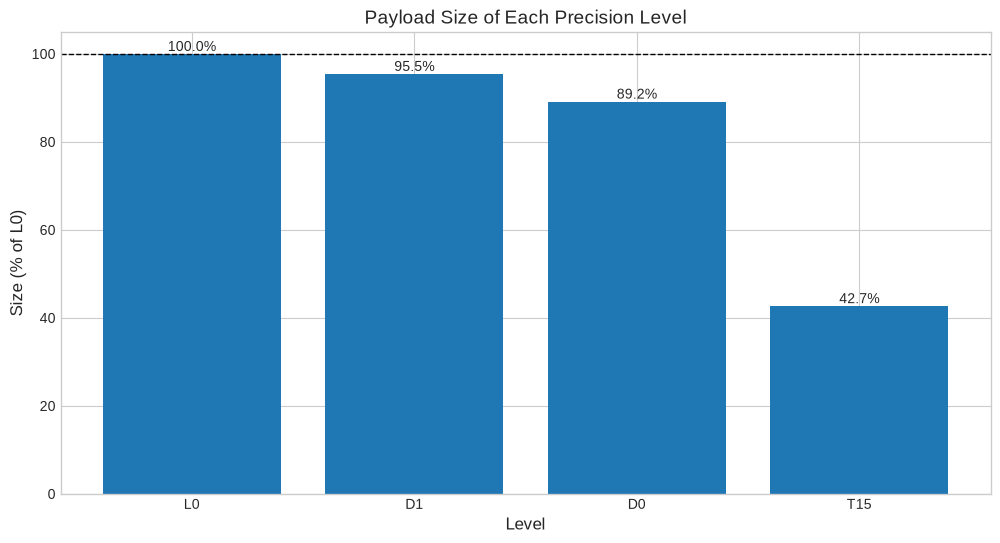

In [7]:
plt.figure(figsize=(12, 6))
bars = plt.bar(summary.index, summary["size_vs_L0_pct"])
plt.bar_label(bars, fmt="%.1f%%")                         # the percentage on top of each bar
plt.axhline(100, color="black", linestyle="--", linewidth=1)
plt.title("Payload Size of Each Precision Level")
plt.xlabel("Level")
plt.ylabel("Size (% of L0)")
plt.savefig(f"{FIGURES}/02_levels.png")
plt.show()

### Step 8 - Saving the Results

In [8]:
summary.to_csv(f"{RESULTS}/02_levels.csv")
spark.stop()